# Coordinates recovery from Binary Range Contact Maps [0,1]

In [426]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.manifold import MDS
import time, os
import pickle as pkl

from scipy.spatial.distance import cdist
from scipy.signal import find_peaks, peak_prominences
import random

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D

from functions import fancy_graphs

## Data

In [136]:
# 4 sets of coordinates, each 120 points

np.random.seed(42)

def generate_uniform(n_points, spread, center=(0, 0, 0), seed=42): # distribution proche de Rayleigh
    np.random.seed(seed)
    def coo():
        return np.random.uniform(0, 1)
    points = np.array([[coo(),coo(),coo()] for _ in range(n_points)]) - 0.5
    points *= spread
    points += center
    return points
    
def generate_gaussian_blobs(centers, points_per_blob=40, dim=3, spread=0.5, seed=42):
    np.random.seed(seed)
    coords = []
    for center in centers:
        blob = np.random.normal(loc=center, scale=spread, size=(points_per_blob, dim))
        coords.append(blob)
    return np.vstack(coords)

coords_collection = []
coords_names = []
dataset_length = 120

# (1) random uniform blob
COORDS = generate_uniform(n_points=dataset_length, spread=25, center=(0,0,0))
print (COORDS.shape)
coords_collection.append(COORDS)
coords_names.append('Uniform Blob')

# (2) multiple gaussian blobs, various scales
CENTERS = np.array([[0.,0.,0.],[-5,0,5],[5,5,5],[0,-5,-5],[3,0,1]])
CENTERS *= 1.4
COORDS = generate_gaussian_blobs(CENTERS, points_per_blob=int(dataset_length/len(CENTERS)), spread=2., seed=42)
print (COORDS.shape)
coords_collection.append(COORDS)
coords_names.append(f'{len(CENTERS)} Gaussian Blobs')

# (3) protein sample
from classes.soft_proteins import *
dirname = "datasets/NANOBODIES/processed"
files = [name for name in os.listdir(dirname) if os.path.isfile(os.path.join(dirname, name))]
filename = f"{os.getcwd()}/{dirname}/{files[0]}"
with open(filename, 'rb') as f:
    data = pkl.load(f)
    protein = Protein(data)
COORDS = np.array(protein.ca[:dataset_length])
print (COORDS.shape)
coords_collection.append(COORDS)
coords_names.append(f'{files[0][:4]} first chain (alpha-carbons)')

(120, 3)
(120, 3)
(120, 3)


In [331]:
def title(s):
    return f"■ \033[1m{s}\033[0m"

def get_mask(length, bandwidth):
    mask = np.zeros((length, length)).astype(bool)
    offset = int((bandwidth - 1) / 2.)
    for i in range(-offset, offset+1):
        np.fill_diagonal(mask.view('bool')[max(0, -i):, max(0, i):], True)
        np.fill_diagonal(mask.view('bool')[min(0, -i):, min(0, i):], True)
    return mask

class Data:
    def __init__(self, coords=False, ranges=4, mask=False, name=False, slicing='percentile', smoothing=5):
        self.coords = coords
        self.name = name
        self.len = len(coords)
        self.ranges = ranges
        self.slicing = slicing
        self.smoothing = smoothing
        
        self._distance_matrix()
        self._configs()
        self._range_matrix()
        self._contact_maps()

        if mask == False:
            self.mask = np.ones((self.len, self.len)).astype(bool)
        else:
            self.mask = mask
            
    def _distance_matrix(self):
        self.distance_matrix = cdist(self.coords, self.coords, metric='euclidean')

    def _contact_maps(self):
        self.contact_maps = np.zeros((self.len, self.len, self.ranges))

        inds = np.triu_indices(self.len, k=1)
        dists = self.distance_matrix[inds]
        bin_ids = np.digitize(dists, self.limits[1:-1], right=False) # assign distance to only one bin
    
        for idx in range(self.ranges):
            selected = (bin_ids == idx)
            i_vals, j_vals = inds[0][selected], inds[1][selected]
            self.contact_maps[i_vals, j_vals, idx] = 1.0
            self.contact_maps[j_vals, i_vals, idx] = 1.0  
    
        for i in range(self.len):
            self.contact_maps[i, i, :] = 0.

    def _range_matrix(self):
        self.range_matrix = np.zeros((self.len, self.len, 2))
        self.range_span = np.ones((self.len, self.len))
        for config in self.configs:
            config_mask = (self.distance_matrix >= config['lower']) & (self.distance_matrix < config['upper'])
            self.range_matrix[config_mask] = np.array([config['lower'], config['upper']])
            span = config['upper'] - config['lower']
            self.range_span[config_mask] = span if span != 0. else 1.
                
        for i in range(self.len):
            self.range_matrix[i,i] = 0.
           
    def _configs(self):
        all_distances = self.distance_matrix[np.triu_indices(self.len, k=1)]
        values = all_distances[all_distances!=0.]
              
        if self.slicing == 'percentile':
                
            self.limits = np.percentile(values, [100*i/self.ranges for i in range(self.ranges+1)])
            self.limits[0] = np.min(values)
            self.configs = [{'lower': self.limits[i], 'upper': self.limits[i+1]} for i in range(len(self.limits)-1)]

        elif self.slicing == 'distance':
              
            min_d, max_d = all_distances.min(), all_distances.max()
            self.limits = [min_d + i*((max_d-min_d)/self.ranges) for i in range(self.ranges)] + [max_d]
            self.limits[0] = min_d
            self.configs = [{'lower': self.limits[i], 'upper': self.limits[i+1]} for i in range(len(self.limits)-1)]
                
        elif self.slicing == 'minima':
                
            counts, bin_edges = np.histogram(values, bins=300)
            kernel_size = max(3, int(self.smoothing))  # e.g., smoothing=5
            kernel = np.ones(kernel_size) / kernel_size
            smoothed = np.convolve(counts, kernel, mode='same')
            minima, _ = find_peaks(-smoothed, prominence=1, distance=15)
                    
            if len(minima) < self.ranges - 1:
                print(f"-> Not enough local minima to create {self.ranges} bins.")
                print("-> Switching to percentile slicing.")
                self.slicing = 'percentile'
                self._configs()
                return
                    
            prominences = peak_prominences(-smoothed, minima)[0]
            top_indices = np.argsort(prominences)[- (self.ranges - 1):]
            chosen_minima = np.sort(minima[top_indices])
            boundary_x = bin_edges[chosen_minima]

            all_edges = np.sort(np.concatenate(([bin_edges[0]], boundary_x, [bin_edges[-1]])))
            bin_centers = [(all_edges[i] + all_edges[i + 1]) / 2 for i in range(len(all_edges) - 1)]
        
            self.limits = bin_edges[chosen_minima].tolist()
            self.limits.insert(0, np.min(values))
            self.limits.insert(-1, np.max(values))
            self.configs = [{'lower': self.limits[i], 'upper': self.limits[i+1]} for i in range(len(self.limits)-1)]

            self.smooth_hist = (bin_edges[:-1], smoothed)
            self.minima = (bin_edges[chosen_minima], smoothed[chosen_minima])

    def clone_masked(self, mask):
        data = Data(self.coords, self.ranges, name=f"{self.name} - masked", slicing=self.slicing)
        data.mask = mask
        data.distance_matrix[~mask] = 0.
        data.range_matrix[~mask] = np.nan
        data.contact_maps[~mask,:] = 0.
        data.configs = self.configs
        return data

    @property
    def stats(self, s=""):
        s += f"{title(f'Data object stats')}\n"
        s += f"Name                 : {self.name}\n"
        s += f"Pairwise data points : {self.len**2: 10.2f}\n"
        s += f"Contact count        : {self.contact_maps.sum(): 10.2f}\n"
        s += f"Mask coverage        : {100*self.mask.sum()/self.len**2 : 10.2f}%"
        return s
        
    def __repr__(self, s=""):
        s += f"Name          : {self.name}\n"
        s += f'Coords        : {self.coords[:3]}\n'
        s += f'Distances     : {self.distance_matrix[0,:3]}\n'
        s += f'Ranges        : {self.range_matrix[0,:3].tolist()}\n'
        s += f'Contact maps  : {self.contact_maps[0,:3].tolist()}'
        return s
        
sample = Data(coords_collection[-1], ranges=6, name='Simple blob', slicing='minima')
print (sample.stats)
data = sample.distance_matrix.ravel()


■ Data object stats
Name                 : Simple blob
Pairwise data points :   14400.00
Contact count        :   14280.00
Mask coverage        :     100.00%


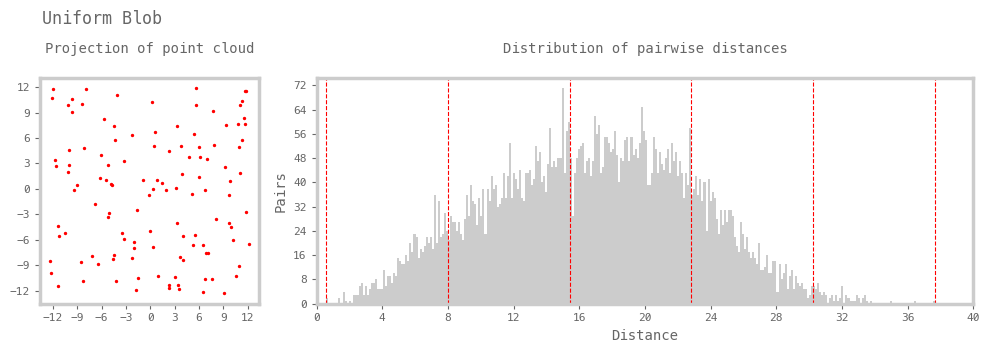

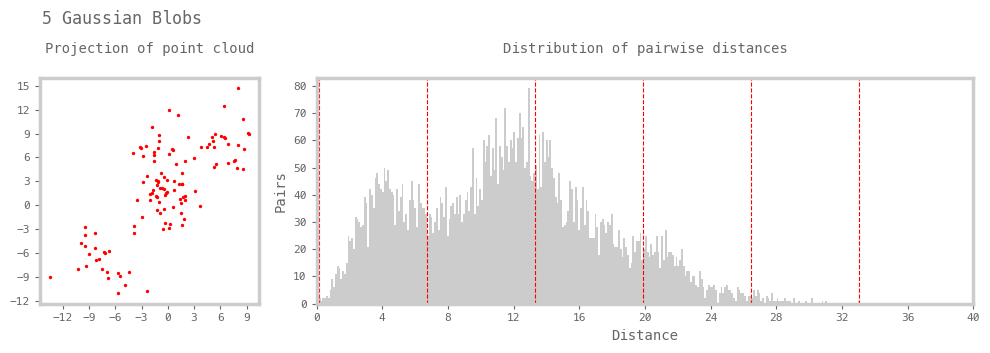

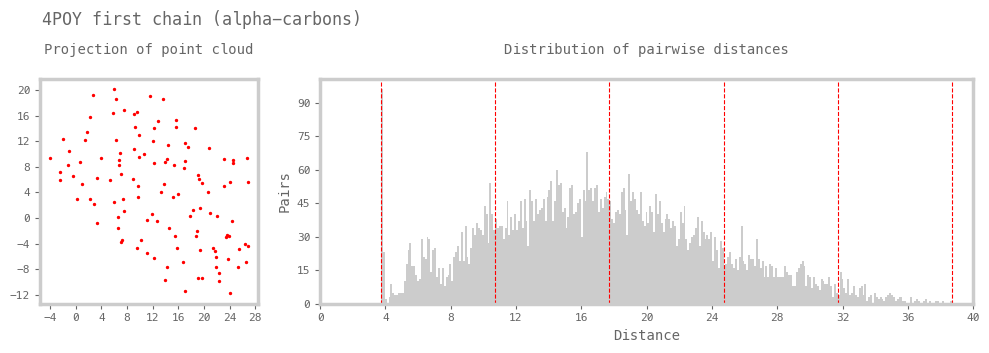

In [332]:
def plot_dataset(self, configs=False, save=False):
    
    all_distances = np.triu(self.distance_matrix).ravel()
    all_distances = all_distances[all_distances != 0.]
    
    fig = plt.figure(figsize=(10,4))
    gs = gridspec.GridSpec(1, 2, width_ratios=[3, 9])
    
    ax1 = fig.add_subplot(gs[1])
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax1.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax1.hist(all_distances, bins=300, color='#CCCCCC')
    ax1.set_xlim(0,40)

    if configs:
        plt.axvline(x=self.configs[0]['lower'], color='red', linestyle='--', linewidth=0.8)
        for config in self.configs:
            plt.axvline(x=config['upper'], color='red', linestyle='--', linewidth=0.8)

    if hasattr(self, 'smooth_hist'):
        plt.plot(self.smooth_hist[0], self.smooth_hist[1], linewidth=0.8)
        plt.plot(self.minima[0], self.minima[1], 'rx')
        
    ax1.set_xlabel('Distance')
    ax1.set_ylabel('Pairs')
    ax1.set_title('\nDistribution of pairwise distances\n')
    
    ax2 = fig.add_subplot(gs[0])
    ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax2.scatter(self.coords[:,1], self.coords[:,2], color='red', s=2.)
    ax2.set_title('\nProjection of point cloud\n')

    plt.suptitle(self.name, y=0.87, x=0.047, ha='left')
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for suptitle
    plt.savefig(f'{self.name}.png', bbox_inches='tight')
    
    _ = plt.show()

Data.plot_dataset = plot_dataset

for i, coords in enumerate(coords_collection):
    sample = Data(coords, ranges=5, name=coords_names[i], slicing='distance', smoothing=10)
    sample.plot_dataset(configs=True, save=True)

## Optimization function

In [333]:
def _sample_distance_matrix(self, save=False):
    N = self.len
    D = np.zeros((N, N))
    
    for i in range(N):
        for j in range(i + 1, N):
            lo, hi = self.range_matrix[i, j]
            if (lo == 0 and hi == 0) or np.isnan(lo):
                continue
            D[i, j] = D[j, i] = np.random.uniform(lo, hi)
    if save:
        self.sample_distance_matrix = D
    else:
        return D
        
def _mds(self, D, dim=3, save=False, verbose=False):
    t0 = time.time()
    if verbose:
        print (title(f"MDS pipeline process - Coordinates recovery with Multi-Dimensional Scaling (MDS)"))
        
    mds = MDS(n_components=dim, dissimilarity='precomputed', metric=True, normalized_stress="auto", random_state=42)
    coords, stress = mds.fit_transform(D), mds.stress_
    t1 = time.time()
    if verbose:
        print (f"MDS Stress          : {stress: 9.2f}")
        print (f"Process time        : {1000*(t1-t0)%60: 9.2f} milliseconds")
    if save:
        self.mds = coords
    else:
        return (coords, stress)

def initialize_coords(self, dim=3):
    self._sample_distance_matrix(save=True)
    self._mds(self.sample_distance_matrix, save=True)
    
Data._sample_distance_matrix = _sample_distance_matrix
Data._mds = _mds
Data.initialize_coords = initialize_coords

In [469]:
def coords_from_cmaps(self, sharpness=10.0, dim=3, lr=1e-3, max_iter=1000, prints=10, verbose=True):
    t0 = time.time()
    
    if verbose:
        print (title("Optimization pipeline process - Gradient-Based Optimization"))

    def compute_pos_weights(contact_maps, local_mask):
        pos_weights = []
        for cmap in contact_maps:
            ratio = max(1.0, local_mask.sum() / (cmap.sum() + 1e-8))
            pos_weight = max(1.0, ratio - 1.0)
            pos_weights.append(pos_weight)
        return pos_weights
    
    def make_local_mask(N, window):
        mask = torch.zeros((N, N), dtype=torch.bool)
        for i in range(N):
            start, end = max(0, i - window), min(N, i + window + 1)
            mask[i, start:end] = True
        return mask
    
    def compute_logits(dists, config, sharpness):
        if config['lower'] == 0:
            return sharpness * (config['upper'] - dists)
        else:
            upper_logits = sharpness * (config['upper'] - dists)
            lower_logits = sharpness * (dists - config['lower'])
            return torch.min(upper_logits, lower_logits)
    
    def apply_weighted_bce(logits, target_map, pos_weight, bce_loss_fn):
        weight_matrix = pos_weight * target_map + (1 - target_map)
        map_loss = bce_loss_fn(logits, target_map)
        return (map_loss * weight_matrix).mean()
    
    assert self.contact_maps.ndim == 3, "Input contact_maps must be shape (N, N, x)"
    N, _, x = self.contact_maps.shape
    assert len(self.configs) == x, "configs length must match number of maps"

    # Initialization
    coords = torch.tensor(self.mds, dtype=torch.float32)
    coords.requires_grad = True
    optimizer = torch.optim.Adam([coords], lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=50)

    contact_maps_tensor = torch.tensor(self.contact_maps, dtype=torch.float32)

    local_mask = torch.tensor(self.mask)
    pos_weights = compute_pos_weights([self.contact_maps[:, :, i] for i in range(x)], local_mask)

    # BCEWithLogitsLoss expects raw logits, and it applies the sigmoid + BCE internally
    bce_loss_fn = torch.nn.BCEWithLogitsLoss(reduction='none') 
    best_loss = float('inf')
    best_coords = coords.clone().detach()
    patience_counter = 0

    for step in range(max_iter):
        optimizer.zero_grad()
        dists = torch.cdist(coords, coords)

        total_loss = torch.tensor(0.0, requires_grad=True)
        partial_losses = []
        for i in range(x):
            logits = compute_logits(dists, self.configs[i], sharpness)
            loss = apply_weighted_bce(logits, contact_maps_tensor[:, :, i], pos_weights[i], bce_loss_fn)
            total_loss = total_loss + loss
            partial_losses.append(loss)

        total_loss.backward()
        torch.nn.utils.clip_grad_norm_([coords], 1.0)
        optimizer.step()
        scheduler.step(total_loss)

        if verbose and step % max(1, int(max_iter // prints)) == 0:
            print(f"Step {step:6d} | Total loss: {total_loss.item():8.3f} | Parts: {[f'{l.item():.2f}' for l in partial_losses]}")

        if total_loss.item() < best_loss:
            best_loss = total_loss.item()
            best_coords = coords.clone().detach()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter > 100:
                if verbose:
                    print(f"Step {step:6d} | Total loss: {total_loss.item():8.3f} | Parts: {[f'{l.item():.2f}' for l in partial_losses]}, early stopping.")
                break

    t1 = time.time()
    
    if verbose:
        print (f"Process time : {int((t1-t0)//60)} minute(s), {(t1-t0)%60:3.1f} seconds")
    
    self.recon_coords = best_coords.detach().numpy()
    self.best_loss = best_loss

Data.coords_from_cmaps = coords_from_cmaps

In [470]:
class Evaluation:
    def __init__(self, truth, reconstructed, mask=False):
        self.D1 = truth
        self.D2 = reconstructed
        if mask is False:
            self.mask = self.D1.mask
        else:
            self.mask = mask

    @property
    def mean_absolute(self):
        return np.abs(self.D1.distance_matrix - self.D2.distance_matrix).mean()

    #@property
    #def weighted_mean_absolute(self):
    #    MAE = np.abs(self.D1.distance_matrix - self.D2.distance_matrix)
    #    return (MAE / self.D1.range_span).mean()

    @property
    def cosine_similarity(self):
        vec1, vec2 = self.D1.distance_matrix.ravel(), self.D2.distance_matrix.ravel()
        dot_product = np.dot(vec1, vec2)
        norm1 = np.linalg.norm(vec1)
        norm2 = np.linalg.norm(vec2)
        if norm1 == 0 or norm2 == 0:
            return 0.0  
        return dot_product / (norm1 * norm2)

    @property
    def mask_coverage(self):
        return 100*self.mask.sum()/self.D1.len**2

    def display(self, vals):
        vals = vals.copy().tolist()
        parts = ["{: 8.4f}".format(v) for v in vals]
        return ' | '.join(parts)

    def print(self, t=""):
        s = f"{title(t) if t != '' else title('Evaluation')}\n"
        s += f"Mask coverage       : {self.mask_coverage: 6.2f}%\n"
        s += f"MAE                 : {self.mean_absolute: 9.6f}\n"
        #s += f"Weighted MAE        : {self.weighted_mean_absolute: 9.6f}\n"
        s += f"Cosine similarity   : {self.cosine_similarity: 9.6f}\n"
        s += f"Ground truth        : {self.display(self.D1.distance_matrix[0, 60:68])}\n"
        s += f"Reconstructed       : {self.display(self.D2.distance_matrix[0, 60:68])}"
        print (s)

    def summary(self, t=""):
        s =  f"{title(t) if t != '' else title('Evaluation')} : "
        s += f"Mask coverage {self.mask_coverage: 6.2f}% | "
        s += f"MAE {self.mean_absolute: 9.6f} | "
        #s += f"Weighted MAE {self.weighted_mean_absolute: 9.6f} | "
        s += f"Cosine similarity {self.cosine_similarity: 9.6f}"
        print (s)


## MDS reduction pipeline on original distance matrix

In [336]:
D1 = Data(coords_collection[0], 6)
D1.initialize_coords()
base_data = D1.distance_matrix

print ()
D1._mds(base_data, verbose=True, save=True)
D2 = Data(D1.mds)
evaluation_1 = Evaluation(D1, D2)

print ()
evaluation_1.print('MDS pipeline evaluation')


■ MDS pipeline process - Coordinates recovery with Multi-Dimensional Scaling (MDS)
MDS Stress          :      0.00
Process time        :     11.39 milliseconds

■ MDS pipeline evaluation
Mask coverage       :  100.00%
MAE                 :  0.000000
Cosine similarity   :  1.000000
Ground truth        :  21.4946 |  21.4757 |  15.6792 |  22.0851 |  18.2319 |   7.0010 |  13.6927 |  21.4291
Reconstructed       :  21.4946 |  21.4757 |  15.6792 |  22.0851 |  18.2319 |   7.0010 |  13.6927 |  21.4291


## MDS reduction pipeline on sample distance matrix

In [337]:
modes = ['percentile', 'distance', 'minima']

for mode in modes:
    
    print ()
    print (f"{mode:.<110s}")
    D1 = Data(coords_collection[2], 6, slicing=mode)
    D1.initialize_coords()
    base_data = D1.sample_distance_matrix # random uniform picks in range
    
    print ()
    D1._mds(base_data, verbose=True, save=True)
    D2 = Data(D1.mds)
    evaluation_1 = Evaluation(D1, D2)
    
    print ()
    evaluation_1.print('MDS pipeline evaluation')


percentile....................................................................................................

■ MDS pipeline process - Coordinates recovery with Multi-Dimensional Scaling (MDS)
MDS Stress          :  60453.81
Process time        :     25.12 milliseconds

■ MDS pipeline evaluation
Mask coverage       :  100.00%
MAE                 :  0.792772
Cosine similarity   :  0.999254
Ground truth        :  27.5538 |  31.3601 |  31.5338 |  30.1840 |  31.4635 |  33.5060 |  32.2841 |  28.5177
Reconstructed       :  28.2380 |  32.1564 |  32.3850 |  30.8895 |  33.1061 |  35.2344 |  32.9107 |  28.8191

distance......................................................................................................

■ MDS pipeline process - Coordinates recovery with Multi-Dimensional Scaling (MDS)
MDS Stress          :  40379.59
Process time        :     15.50 milliseconds

■ MDS pipeline evaluation
Mask coverage       :  100.00%
MAE                 :  0.434489
Cosine similarity   :  0.9

## MDS reduction pipeline on sample distance matrix, <u>partial</u>

In [354]:
BANDWIDTH = 60
MASK = get_mask(dataset_length, bandwidth=BANDWIDTH)
DATASET_IDX = 0

for mode in modes:
    
    print ()
    print (f"{mode:.<110s}")
    D1 = Data(coords_collection[DATASET_IDX], 6, slicing=mode, name=coords_names[DATASET_IDX])
    D1.initialize_coords()

    D_masked = D1.clone_masked(MASK)

    print ()
    D_masked._mds(D_masked._sample_distance_matrix(), verbose=True, save=True)
    D2 = Data(D_masked.mds)
    evaluation_1 = Evaluation(D1, D2, mask=MASK)
    
    print ()
    evaluation_1.print('MDS pipeline evaluation')


percentile....................................................................................................

■ MDS pipeline process - Coordinates recovery with Multi-Dimensional Scaling (MDS)
MDS Stress          :  624932.66
Process time        :     15.61 milliseconds

■ MDS pipeline evaluation
Mask coverage       :  40.83%
MAE                 :  9.576614
Cosine similarity   :  0.969198
Ground truth        :  21.4946 |  21.4757 |  15.6792 |  22.0851 |  18.2319 |   7.0010 |  13.6927 |  21.4291
Reconstructed       :   7.9385 |   7.5850 |   4.5627 |   8.6073 |   5.3446 |   4.2534 |   1.8095 |  10.4705

distance......................................................................................................

■ MDS pipeline process - Coordinates recovery with Multi-Dimensional Scaling (MDS)
MDS Stress          :  555502.89
Process time        :     36.33 milliseconds

■ MDS pipeline evaluation
Mask coverage       :  40.83%
MAE                 :  9.902740
Cosine similarity   :  0.9

## MDS systematic evaluation

In [378]:
class Experiment:
    def __init__(self, name, data_name, slicing, n_ranges, bandwidth, evaluation=False):
        self.name = name
        self.data_name = data_name
        self.slicing = slicing
        self.n_ranges = n_ranges
        self.bandwidth = bandwidth
        self.evaluation = evaluation
        self.timestamp = time.time()

    def __repr__(self, s=""):
        s += f"Experiment name : {self.name}\n"
        s += f"Dataset :         {self.data_name}\n"
        s += f"Slicing :         {self.slicing}\n"
        s += f"Ranges :          {self.n_ranges}\n"
        s += f"Bandwidth :       {self.bandwidth}\n"
        return s

In [435]:
mds_experiments = []
ranges = list(range(4, 8))
bandwidths = list(range(10, dataset_length+1, 5))
exp_cnt = len(coords_collection)*len(modes)*len(ranges)*len(bandwidths)

print ()
print (f"About to run {exp_cnt} experiments, this may take some time ...")
print (f"Around {exp_cnt*0.0085:5.2f} minutes")
print ()


About to run 828 experiments, this may take some time ...
Around  7.45 minutes



In [436]:
print()
t0 = time.time()
for coo_idx, coords in enumerate(coords_collection):
    for mode in modes:
        for n_ranges in ranges:
            
            D = Data(coords, ranges=n_ranges, name=coords_names[coo_idx], slicing=mode)
            
            for bandwidth in bandwidths:
    
                experiment = Experiment(name =  f"{coords_names[coo_idx]}_{n_ranges}_{mode}", 
                                    slicing =   D.slicing,  
                                    data_name = D.name,
                                    n_ranges =  D.ranges,
                                    bandwidth = bandwidth)
                
                mask = get_mask(len(coords), bandwidth=bandwidth)
                D_masked = D.clone_masked(mask)
                D_masked.initialize_coords()
    
                D_masked._mds(D_masked._sample_distance_matrix(), verbose=False, save=True)
                D2 = Data(D_masked.mds)
                
                evaluation = Evaluation(D, D2, mask=mask)
                evaluation.summary(f'{D.name}, {n_ranges} channels, BW {bandwidth: 3d}, {mode: <10s}')
                
                experiment.evaluation = evaluation
                mds_experiments.append(experiment)

t1 = time.time()
print (f"Process time : {(t1-t0)//60:2.0f} minutes, {(t1-t0)%60:3.1f} seconds")

with open(os.getcwd()+'/experiments/optim_experiments_mds.pkl','wb') as f:
    pkl.dump(mds_experiments, f)


■ Uniform Blob, 4 channels, BW  10, percentile : Mask coverage   7.50% | MAE  15.305645 | Cosine similarity  0.904223
■ Uniform Blob, 4 channels, BW  15, percentile : Mask coverage  12.50% | MAE  14.409869 | Cosine similarity  0.912478
■ Uniform Blob, 4 channels, BW  20, percentile : Mask coverage  15.83% | MAE  13.816880 | Cosine similarity  0.909480
■ Uniform Blob, 4 channels, BW  25, percentile : Mask coverage  20.83% | MAE  12.865791 | Cosine similarity  0.945396
■ Uniform Blob, 4 channels, BW  30, percentile : Mask coverage  24.17% | MAE  12.313373 | Cosine similarity  0.934795
■ Uniform Blob, 4 channels, BW  35, percentile : Mask coverage  29.17% | MAE  11.444035 | Cosine similarity  0.957710
■ Uniform Blob, 4 channels, BW  40, percentile : Mask coverage  32.50% | MAE  10.858824 | Cosine similarity  0.972979
■ Uniform Blob, 4 channels, BW  45, percentile : Mask coverage  37.50% | MAE  10.054778 | Cosine similarity  0.953883
■ Uniform Blob, 4 channels, BW  50, percentile : Mask c

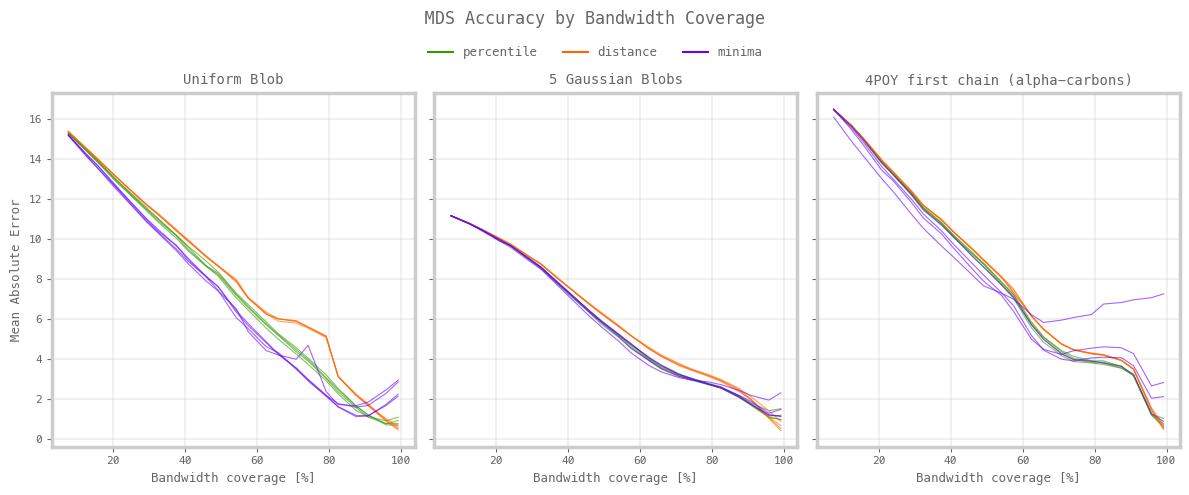

In [482]:
mode_colors = ['#339900','#FF6600','#6600FF']

fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=True)

for ax, name in zip(axes, coords_names):
    selection = [exp for exp in mds_experiments if exp.data_name == name]

    for m_idx, mode in enumerate(modes):
        color = mode_colors[m_idx]

        for i, n_ranges in enumerate(ranges):
            x = [exp.evaluation.mask_coverage for exp in selection if exp.n_ranges == n_ranges and exp.slicing == mode]
            y = [exp.evaluation.mean_absolute for exp in selection if exp.n_ranges == n_ranges and exp.slicing == mode]

            ax.plot(x, y, color=color, linewidth=0.8, alpha=0.6)

    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Bandwidth coverage [%]", fontsize=9)
    ax.grid(True)

axes[0].set_ylabel("Mean Absolute Error", fontsize=9)

custom_legend = [Line2D([0], [0], color=mode_colors[i], lw=1.5, label=modes[i]) for i in range(len(modes))]

fig.legend(handles=custom_legend, loc='upper center', ncol=len(modes), fontsize=9, frameon=False, bbox_to_anchor=(0.5, 0.93))

fig.suptitle("MDS Accuracy by Bandwidth Coverage")
fig.tight_layout(rect=[0, 0, 1, 0.95])  

plt.savefig("mds_accuracy_grid.png", dpi=300)
plt.show()

## Optimization pipeline

In [464]:
BANDWIDTH = 60
MASK = get_mask(len(COORDS), bandwidth=BANDWIDTH)
DATASET_IDX = 0

for mode in modes:
    
    print ()
    print (f"{mode:.<110s}")
    D1 = Data(coords_collection[DATASET_IDX], 6, slicing=mode, name=coords_names[DATASET_IDX])
    D1.initialize_coords()
    
    D_masked = D1.clone_masked(MASK)
    print ()
    print (D_masked.stats)
    
    D_masked.initialize_coords()
    
    print ()
    D_masked._mds(D_masked.sample_distance_matrix, verbose=True, save=True)
    D2 = Data(D_masked.mds)
    
    print ()
    evaluation_1 = Evaluation(D1, D2, mask=MASK)
    evaluation_1.print('MDS pipeline evaluation')
    
    print ()
    D_masked.coords_from_cmaps(sharpness=15.0, max_iter=10000, prints=10, verbose=True)
    D2 = Data(D_masked.recon_coords)
    
    print ()
    evaluation_2 = Evaluation(D1, D2, mask=MASK)
    evaluation_2.print('Optimization pipeline evaluation')



percentile....................................................................................................

■ Data object stats
Name                 : Uniform Blob - masked
Pairwise data points :   14400.00
Contact count        :    6960.00
Mask coverage        :      49.17%

■ MDS pipeline process - Coordinates recovery with Multi-Dimensional Scaling (MDS)
MDS Stress          :  650489.86
Process time        :     23.94 milliseconds

■ MDS pipeline evaluation
Mask coverage       :  49.17%
MAE                 :  8.115705
Cosine similarity   :  0.980736
Ground truth        :  21.4946 |  21.4757 |  15.6792 |  22.0851 |  18.2319 |   7.0010 |  13.6927 |  21.4291
Reconstructed       :  10.8712 |  11.7617 |   8.5469 |  11.8395 |  10.4094 |   5.2265 |   5.6759 |  11.4093

■ Optimization pipeline process - Gradient-Based Optimization
Step      0 | Total loss:  245.588 | Parts: ['22.36', '25.18', '37.36', '46.18', '54.79', '59.71']
Step   1000 | Total loss:  168.175 | Parts: ['12.29', '17.

## Experiments

In [479]:
gbo_experiments = []
ranges = list(range(4, 9))
bandwidths = list(range(10, dataset_length+1, 5))
exp_cnt = len(coords_collection)*len(modes)*len(ranges)*len(bandwidths)

print ()
print (f"About to run {exp_cnt} experiments, this may take some time ...")
print (f"Around {exp_cnt*0.85:5.2f} minutes")
print ()


About to run 1035 experiments, this may take some time ...
Around 517.50 minutes



In [480]:
print()
t0 = time.time()
for coo_idx, coords in enumerate(coords_collection):
    for mode in modes:
        for n_ranges in ranges:
            
            D = Data(coords, ranges=n_ranges, name=coords_names[coo_idx], slicing=mode)
            
            for bandwidth in bandwidths:
    
                experiment = Experiment(name =  f"{coords_names[coo_idx]}_{n_ranges}_{mode}", 
                                    slicing =   D.slicing,  
                                    data_name = D.name,
                                    n_ranges =  D.ranges,
                                    bandwidth = bandwidth)
                
                mask = get_mask(len(coords), bandwidth=bandwidth)
                D_masked = D.clone_masked(mask)
                D_masked.initialize_coords()
                D_masked.coords_from_cmaps(sharpness=15.0, max_iter=10000, prints=10, verbose=False)
                
                D2 = Data(D_masked.recon_coords)
                
                evaluation = Evaluation(D, D2, mask=mask)
                evaluation.summary(f'{D.name}, {n_ranges} channels, BW {bandwidth: 3d}, {mode: <10s}')
                
                experiment.evaluation = evaluation
                gbo_experiments.append(experiment)

t1 = time.time()
print (f"Total process time : {(t1-t0)//60:2.0f} minutes, {(t1-t0)%60:3.1f} seconds")

with open(os.getcwd()+'/experiments/optim_experiments_gbo.pkl','wb') as f:
    pkl.dump(gbo_experiments, f)



■ Uniform Blob, 4 channels, BW  10, percentile : Mask coverage   7.50% | MAE  16.203849 | Cosine similarity  0.889719
■ Uniform Blob, 4 channels, BW  15, percentile : Mask coverage  12.50% | MAE  16.149693 | Cosine similarity  0.898615
■ Uniform Blob, 4 channels, BW  20, percentile : Mask coverage  15.83% | MAE  16.111199 | Cosine similarity  0.899259
■ Uniform Blob, 4 channels, BW  25, percentile : Mask coverage  20.83% | MAE  15.685022 | Cosine similarity  0.443386
■ Uniform Blob, 4 channels, BW  30, percentile : Mask coverage  24.17% | MAE  7.434215 | Cosine similarity  0.862639
■ Uniform Blob, 4 channels, BW  35, percentile : Mask coverage  29.17% | MAE  5.058490 | Cosine similarity  0.936577
■ Uniform Blob, 4 channels, BW  40, percentile : Mask coverage  32.50% | MAE  4.201432 | Cosine similarity  0.954466
■ Uniform Blob, 4 channels, BW  45, percentile : Mask coverage  37.50% | MAE  4.828460 | Cosine similarity  0.934587
■ Uniform Blob, 4 channels, BW  50, percentile : Mask cover

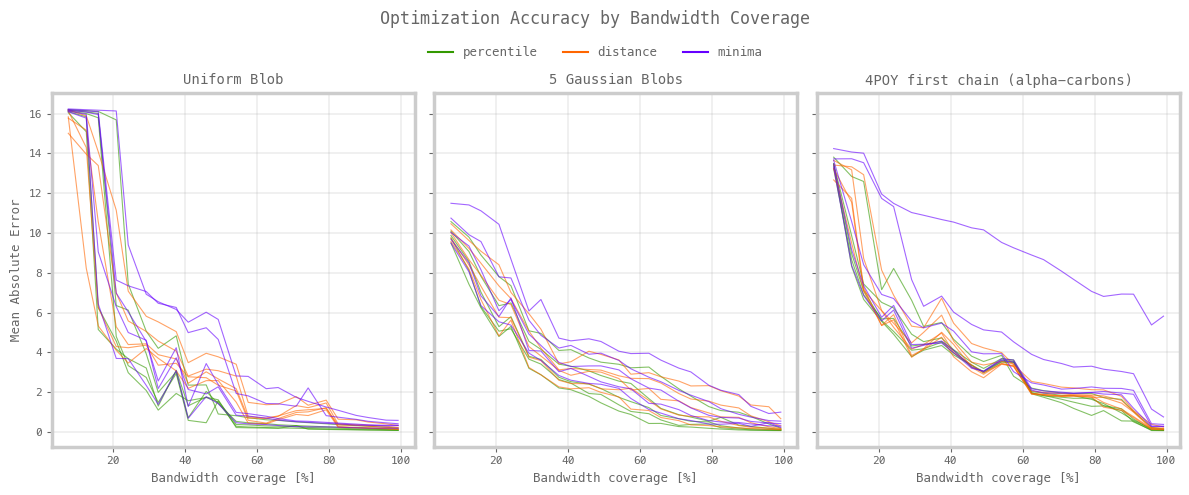

In [483]:
mode_colors = ['#339900','#FF6600','#6600FF']

fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=True)

for ax, name in zip(axes, coords_names):
    selection = [exp for exp in gbo_experiments if exp.data_name == name]

    for m_idx, mode in enumerate(modes):
        color = mode_colors[m_idx]

        for i, n_ranges in enumerate(ranges):
            x = [exp.evaluation.mask_coverage for exp in selection if exp.n_ranges == n_ranges and exp.slicing == mode]
            y = [exp.evaluation.mean_absolute for exp in selection if exp.n_ranges == n_ranges and exp.slicing == mode]

            ax.plot(x, y, color=color, linewidth=0.8, alpha=0.6)

    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Bandwidth coverage [%]", fontsize=9)
    ax.grid(True)

axes[0].set_ylabel("Mean Absolute Error", fontsize=9)

# Custom legend
custom_legend = [
    Line2D([0], [0], color=mode_colors[i], lw=1.5, label=modes[i]) for i in range(len(modes))
]

fig.legend(handles=custom_legend, loc='upper center', ncol=len(modes), fontsize=9, frameon=False, bbox_to_anchor=(0.5, 0.93))

fig.suptitle("Optimization Accuracy by Bandwidth Coverage")
fig.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for suptitle

plt.savefig("gbo_accuracy_grid.png", dpi=300)
plt.show()

## Revised optimization pipeline, protein specific

In [421]:
def coords_from_cmaps(self, sharpness=10.0, dim=3, lr=1e-3, max_iter=1000, prints=10, verbose=True):

    if verbose:
        print (title("Optimization pipeline process - Gradient-Based Optimization"))

    def compute_pos_weights(contact_maps, local_mask):
        pos_weights = []
        for cmap in contact_maps:
            ratio = max(1.0, local_mask.sum() / (cmap.sum() + 1e-8))
            pos_weight = max(1.0, ratio - 1.0)
            pos_weights.append(pos_weight)
        return pos_weights
    
    def make_local_mask(N, window):
        mask = torch.zeros((N, N), dtype=torch.bool)
        for i in range(N):
            start, end = max(0, i - window), min(N, i + window + 1)
            mask[i, start:end] = True
        return mask
    
    def compute_logits(dists, config, sharpness):
        if config['lower'] == 0:
            return sharpness * (config['upper'] - dists)
        else:
            upper_logits = sharpness * (config['upper'] - dists)
            lower_logits = sharpness * (dists - config['lower'])
            return torch.min(upper_logits, lower_logits)
    
    def apply_weighted_bce(logits, target_map, pos_weight, bce_loss_fn):
        weight_matrix = pos_weight * target_map + (1 - target_map)
        map_loss = bce_loss_fn(logits, target_map)
        return (map_loss * weight_matrix).mean()

    def repulsion_term(dists, min_distance, mask):
        min_dist_violation = torch.relu(min_distance - dists)
        return (min_dist_violation[mask] ** 2).sum()
    
    assert self.contact_maps.ndim == 3, "Input contact_maps must be shape (N, N, x)"
    N, _, x = self.contact_maps.shape
    assert len(self.configs) == x, "configs length must match number of maps"

    # Initialization
    coords = torch.tensor(self.mds, dtype=torch.float32)
    coords.requires_grad = True
    optimizer = torch.optim.Adam([coords], lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=50)

    contact_maps_tensor = torch.tensor(self.contact_maps, dtype=torch.float32)
    repulsion_mask = ~torch.eye(N, dtype=torch.bool)
    local_mask = torch.tensor(self.mask)
    pos_weights = compute_pos_weights([self.contact_maps[:, :, i] for i in range(x)], local_mask)

    # BCEWithLogitsLoss expects raw logits, and it applies the sigmoid + BCE internally
    bce_loss_fn = torch.nn.BCEWithLogitsLoss(reduction='none') 
    best_loss = float('inf')
    best_coords = coords.clone().detach()
    patience_counter = 0

    for step in range(max_iter):
        optimizer.zero_grad()
        dists = torch.cdist(coords, coords)

        # Regularization losses
        sequential_dists = torch.diag(dists, diagonal=1)
        connectivity_loss = ((sequential_dists - 3.8) ** 2).mean()
        repulsion_loss = repulsion_term(dists, min_distance=2.3, mask=repulsion_mask)

        # Main loss from all contact maps
        total_loss = torch.tensor(0.0, requires_grad=True)
        partial_losses = []
        for i in range(x):
            logits = compute_logits(dists, self.configs[i], sharpness)
            loss = apply_weighted_bce(logits, contact_maps_tensor[:, :, i], pos_weights[i], bce_loss_fn)
            total_loss = total_loss + loss
            partial_losses.append(loss)

        total_loss += 0.1 * repulsion_loss + 0.05 * connectivity_loss

        total_loss.backward()
        torch.nn.utils.clip_grad_norm_([coords], 1.0)
        optimizer.step()
        scheduler.step(total_loss)

        if verbose and step % max(1, int(max_iter // prints)) == 0:
            print(f"Step {step:6d} | Total loss: {total_loss.item():8.3f} | Parts: {[f'{l.item():.2f}' for l in partial_losses]}")

        if total_loss.item() < best_loss:
            best_loss = total_loss.item()
            best_coords = coords.clone().detach()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter > 100:
                if verbose:
                    print(f"Step {step:6d} | Total loss: {total_loss.item():8.3f} | Parts: {[f'{l.item():.2f}' for l in partial_losses]}, early stopping.")
                break

    self.recon_coords = best_coords.detach().numpy()
    self.best_loss = best_loss

Data.coords_from_cmaps = coords_from_cmaps

In [422]:
D1 = Data(coords_collection[-1], 6)
D1.initialize_coords()

BANDWIDTH = 60
MASK = get_mask(dataset_length, bandwidth=BANDWIDTH)

D_masked = D1.clone_masked(MASK)
print ()
print (D_masked.stats)

D_masked.initialize_coords()

print ()
D_masked._mds(D_masked.sample_distance_matrix, verbose=True, save=True)
D2 = Data(D_masked.mds)

print ()
evaluation_1 = Evaluation(D1, D2, mask=MASK)
evaluation_1.print('MDS pipeline evaluation')

print ()
D_masked.coords_from_cmaps(sharpness=15.0, max_iter=10000, prints=10, verbose=True)
D2 = Data(D_masked.recon_coords)

print ()
evaluation_2 = Evaluation(D1, D2, mask=MASK)
evaluation_2.print('Optimization pipeline evaluation')



■ Data object stats
Name                 : False
Pairwise data points :   14400.00
Contact count        :    6960.00
Mask coverage        :      49.17%

■ MDS pipeline process - Coordinates recovery with Multi-Dimensional Scaling (MDS)
MDS Stress          :  577536.69
Process time        :      1.25 milliseconds

■ MDS pipeline evaluation
Mask coverage       :  49.17%
MAE                 :  8.746885
Cosine similarity   :  0.937631
Ground truth        :  27.5538 |  31.3601 |  31.5338 |  30.1840 |  31.4635 |  33.5060 |  32.2841 |  28.5177
Reconstructed       :  12.0939 |  13.3665 |  12.6178 |  11.1629 |  11.6543 |  11.7930 |  10.4279 |   8.5716

■ Optimization pipeline process - Gradient-Based Optimization
Step      0 | Total loss:  239.580 | Parts: ['15.75', '18.90', '31.42', '41.40', '50.78', '58.42']
Step   1000 | Total loss:  150.653 | Parts: ['12.10', '12.31', '19.40', '27.17', '35.14', '42.24']
Step   2000 | Total loss:   92.880 | Parts: ['11.24', '9.84', '11.13', '14.50', '20.30'

In [424]:
# All right, now how much of "partial" is enough ?
# And how many contact maps do we need ?

second_experiments = []
ranges = [6]
bandwidths = list(range(4, dataset_length, 4))
coords = coords_collection[-1]

print ()
for n_ranges in ranges:
    
    D = Data(coords, ranges=n_ranges, name=coords_names[-1])
    
    for bandwidth in bandwidths:

        experiment = Experiment(name =  f"{coords_names[-1]}_{n_ranges}", 
                            data_name = D.name,
                            n_ranges =  D.ranges,
                            bandwidth = bandwidth)
        
        mask = get_mask(len(coords), bandwidth=bandwidth)
        D_masked = D.clone_masked(mask)
        D_masked.initialize_coords()
        D_masked.coords_from_cmaps(sharpness=15.0, max_iter=10000, prints=10, verbose=False)
        D2 = Data(D_masked.recon_coords)
        
        evaluation = Evaluation(D, D2, mask=mask)
        evaluation.summary(f'{D.name}, {n_ranges} channels, bandwidth {bandwidth: 3d}')
        
        experiment.evaluation = evaluation
        second_experiments.append(experiment)
    


■ AA chain, 6 channels, bandwidth   4 : Mask coverage   2.50% | MAE  9.323158 | Cosine similarity  0.870936
■ AA chain, 6 channels, bandwidth   8 : Mask coverage   5.83% | MAE  8.994537 | Cosine similarity  0.868779
■ AA chain, 6 channels, bandwidth  12 : Mask coverage   9.17% | MAE  8.141545 | Cosine similarity  0.873796
■ AA chain, 6 channels, bandwidth  16 : Mask coverage  12.50% | MAE  7.431732 | Cosine similarity  0.874846
■ AA chain, 6 channels, bandwidth  20 : Mask coverage  15.83% | MAE  6.591216 | Cosine similarity  0.896402
■ AA chain, 6 channels, bandwidth  24 : Mask coverage  19.17% | MAE  5.990178 | Cosine similarity  0.909449
■ AA chain, 6 channels, bandwidth  28 : Mask coverage  22.50% | MAE  5.799797 | Cosine similarity  0.910061
■ AA chain, 6 channels, bandwidth  32 : Mask coverage  25.83% | MAE  4.629028 | Cosine similarity  0.949769
■ AA chain, 6 channels, bandwidth  36 : Mask coverage  29.17% | MAE  4.045937 | Cosine similarity  0.964517
■ AA chain, 6 channels, ban

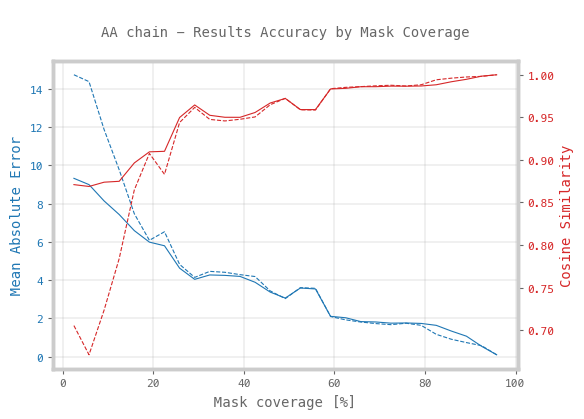

In [430]:
fig, ax1 = plt.subplots(figsize=(6,4))
name = coords_names[-1]
selection1 = [exp for exp in experiments if exp.data_name == name]
selection2 = [exp for exp in second_experiments if exp.data_name == name]

for i, n_ranges in enumerate(ranges):
    x = [exp.evaluation.mask_coverage for exp in selection1 if exp.n_ranges == n_ranges]
    y11 = [exp.evaluation.mean_absolute for exp in selection1 if exp.n_ranges == n_ranges]
    y21 = [exp.evaluation.cosine_similarity for exp in selection1 if exp.n_ranges == n_ranges]
    y12 = [exp.evaluation.mean_absolute for exp in selection2 if exp.n_ranges == n_ranges]
    y22 = [exp.evaluation.cosine_similarity for exp in selection2 if exp.n_ranges == n_ranges]
    
    ax1.plot(x, y11, color='tab:blue', linewidth=.8, linestyle='--', label='Mean Absolute Error')
    ax1.plot(x, y12, color='tab:blue', linestyle='-', linewidth=.8)
    
    ax1.set_xlabel("Mask coverage [%]")
    ax1.set_ylabel("Mean Absolute Error", color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    
    if i==0:
        ax2 = ax1.twinx()
        ax2.set_ylabel("Cosine Similarity", color='tab:red')

    ax2.plot(x, y21, color='tab:red', linewidth=.8, linestyle='--', label='Cosine Similarity')
    ax2.plot(x, y22, color='tab:red', linewidth=.8, linestyle='-')
    ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title(f'\n{name} - Results Accuracy by Mask Coverage\n')
ax1.grid(True)

plt.show()